In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7" 

In [16]:
import json
import os
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
from jaxued.environments.underspecified_env import EnvParams, EnvState, UnderspecifiedEnv
from jaxued.utils import compute_max_mean_returns_epcount
import optax
from flax import struct
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.maze.env_editor import LocalKeyMazeEditorRotateSplitAct
from jaxued.linen import ResetRNN
from jaxued.environments import Maze, MazeRenderer, ObservedMazeRenderer, SokobanMaze
from jaxued.environments.maze import Level, ObservedLevel, make_level_generator
from jaxued.wrappers import AutoReplayWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

In [7]:
from omegaconf import OmegaConf
from hydra import initialize, compose


def load_hydra_config(config_path, config_name):
    # Initialize the Hydra context
    with initialize(config_path=config_path):
        # Compose the configuration
        cfg = compose(config_name=config_name)
        return cfg
    
config_path = "config"  # path to the directory containing the config file
config_name = "main_obs_gen"  # name of the config file without the extension

config = load_hydra_config(config_path, config_name)

if config["num_env_steps"] is not None:
    config["num_updates"] = config["num_env_steps"] // (config["num_train_envs"] * config["num_steps"])

if config['mode'] == 'eval':
    os.environ['WANDB_MODE'] = 'disabled'
    

/tmp/ipykernel_478036/3239372705.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_path):


In [17]:
env = SokobanMaze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=True)
sample_random_level = make_level_generator(env.max_height, env.max_width, 60)
adv_env = LocalKeyMazeEditorRotateSplitAct(env, random_z_dimensions=config['adv_random_z_dimension'], zero_out_random_z=config['adv_zero_out_random_z'], num_agents=1, agent_view_size=5)
adv_env_renderer = ObservedMazeRenderer(env, tile_size=8)
env_renderer = MazeRenderer(env, tile_size=8)
env = AutoReplayWrapper(env)
env_params = env.default_params
adv_env_params = adv_env.default_params

def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        observation_map=jnp.zeros((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([1, 1], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def sample_random_init_level(rng):
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    rng_pos, rng_dir = jax.random.split(rng)
    agent_pos = jax.random.randint(rng_pos, (2,), 0, jnp.array([h, w]), dtype=jnp.uint32)
    agent_dir = jax.random.randint(rng_dir, (), 0, 4, dtype=jnp.uint8)
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        observation_map=observation_map.at[agent_pos[1], agent_pos[0]].set(True),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=agent_pos,
        agent_dir=agent_dir,
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

rng = jax.random.PRNGKey(14532)
rng, _rng = jax.random.split(rng)

In [ ]:
# ADVERSARY INIT
rng, rng_reset, rng_lvl = jax.random.split(rng, 3)
init_adv_obs, init_adv_env_state = adv_env.reset_to_level(rng_reset, sample_random_init_level(rng_lvl), adv_env_params)
adv_state = init_adv_env_state
adv_obs = init_adv_obs

# PROTAGONIST INIT
rng, rng_reset = jax.random.split(rng, 2)
pro_init_obs, pro_init_env_state = env.reset_to_level(rng_reset, adv_state.level, env_params)
pro_env_state = pro_init_env_state
pro_obs = pro_init_obs


In [ ]:
# EXAMPLE ADV ACTION
action = jnp.array([9, 3])

rng, _rng = jax.random.split(rng)
adv_obs, adv_next_state, adv_reward, adv_done, _ = adv_env.step(_rng, adv_state, action, env_params)
adv_state = adv_next_state

pro_obs, pro_env_state = env.update_state_from_level(adv_state.level, pro_env_state)

In [58]:
# FILL CURRENT SPACE
total_actions = 0
while not (~adv_obs.action_mask[0]).all():
    total_actions += 1
    rng, rng_act, rng_step = jax.random.split(rng, 3)
    action_1 = jax.random.choice(rng_act, jnp.arange(25)[adv_obs.action_mask[0]])
    action_2 = jax.random.choice(rng_act, jnp.arange(5)[adv_obs.action_mask[1]])
    adv_obs, adv_next_state, adv_reward, adv_done, _ = adv_env.step(rng_step, adv_state, jnp.array([action_1, action_2]), env_params)
    adv_state = adv_next_state

pro_obs, pro_env_state = env.update_state_from_level(adv_state.level, pro_env_state)

In [56]:
# TAKE PRO STEP

rng, _rng = jax.random.split(rng)
obs, next_state, reward, done, _ = env.step(_rng, pro_env_state, 1, env_params)

next_locs = next_state.env_state.agent_pos.reshape(1, 2)
next_dirs = next_state.env_state.agent_dir.reshape(1)

pro_env_state = next_state
adv_state = adv_state.replace(agent_locs=next_locs, agent_dirs=next_dirs)
rng, _rng = jax.random.split(rng)
adv_obs = adv_env.get_finished_obs(_rng, adv_state, jnp.array([True]))


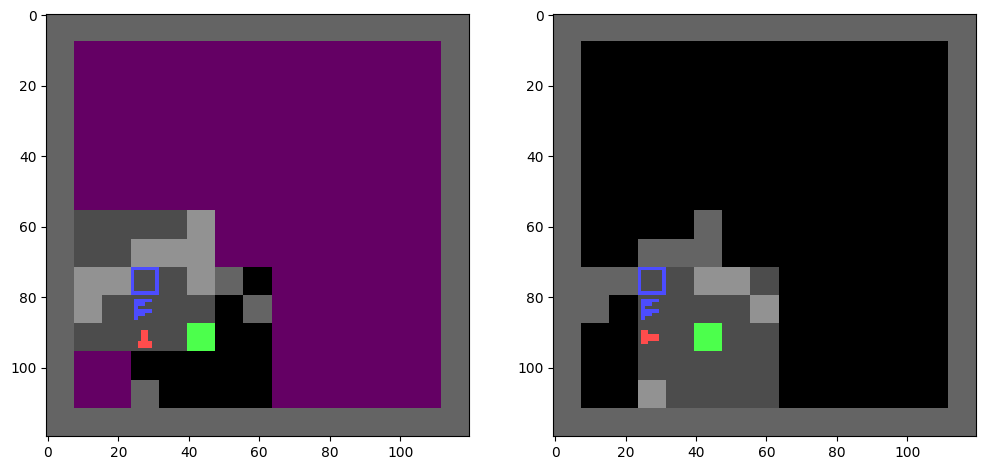

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

adv_state_image = adv_env_renderer.render_state(adv_state.level, env_params)
pro_state_image = env_renderer.render_state(pro_env_state.env_state, env_params)

axes[0].imshow(adv_state_image)
axes[1].imshow(pro_state_image)

# axes[1].imshow(adv_obs.image[:, :, 0:3])
# #axes[2].imshow(adv_obs.image[:, :, 3:6])

# axes[2].imshow(adv_obs.observation_map[:, :, 0])
# #axes[4].imshow(adv_obs.observation_map[:, :, 1])